In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from Tracer import WindField, solver, initial_velocity

# Data from tour averages for the men's (PGA) and women's (LPGA) golf turnaments
# from https://www.trackman.com/blog/golf/introducing-updated-tour-averages

df = pd.read_csv("shotdata.csv", sep="	", decimal=",")
display(df)

,TriggerTimestamp [UTC Timestamp],Carry [m],BallSpeed [m/s],LaunchDirection [deg],LaunchAngle [deg],SpinAxis [deg],SpinRate [rpm],MaxHeight [m]
0,2025-11-23T13:55:45.562607885Z,231.49,73.81,6.48,6.48,-10.46,3001.06,21.54
1,2025-11-23T13:56:17.733195258Z,239.18,77.19,4.49,6.07,-12.28,3194.55,23.34
2,2025-11-23T13:56:58.824687885Z,256.70,78.25,-1.02,9.37,3.02,2754.65,32.21
3,2025-11-23T14:06:30.814009138Z,240.44,72.10,2.38,12.23,-5.36,2551.07,31.82
4,2025-11-23T14:07:13.575407885Z,225.59,75.71,0.60,7.01,-9.79,2582.97,19.18
...,...,...,...,...,...,...,...,...
68,2025-11-23T17:47:33.775227837Z,250.71,77.00,1.03,11.32,-3.35,1933.64,30.72
69,2025-11-23T17:55:23.133966343Z,254.76,77.02,2.95,11.40,1.35,2917.14,35.69
70,2025-11-23T17:56:11.908530969Z,255.54,79.60,2.86,11.94,-4.83,2048.87,34.75
71,2025-11-23T18:04:16.310469090Z,246.82,76.85,1.89,9.33,-4.79,3294.29,32.89


In [24]:
P0 = [0,0,0]
directions = [0, 45, 135, 180] #[*range(0, 360, 45)]
DT = 0.1

def calculate_trajectory_metrics(df, wind_profile):
    """Calculate carry and max height for all clubs in dataframe."""
    carry = []
    max_height = []
    
    for i in range(len(df)):
        total_carry = 0
        total_height = 0
        
        V0 = initial_velocity(speed=df['BallSpeed [m/s]'][i], angle=df['LaunchAngle [deg]'][i])
        W0 = np.array([0, -df['SpinRate [rpm]'][i], 0])
        
        for dir in directions:
            wind = WindField(nx=300, ny=50, nz=50, direction=dir, profile=wind_profile, z0=0.003, U_ref=0)
            t, p, v, w = solver(P0, V0, W0, wind, dt=DT)
            total_carry += ((p[-1][0] - p[0][0])**2 + (p[-1][1] - p[0][1])**2)**0.5
            total_height += max(p[:,2])
        
        num_directions = len(directions)
        carry.append(total_carry / num_directions)
        max_height.append(total_height / num_directions)
    
    return carry, max_height

# %%
carry_pga, maxheight_pga = calculate_trajectory_metrics(df, 'log')
carry_lpga, maxheight_lpga = calculate_trajectory_metrics(df, 'uniform')

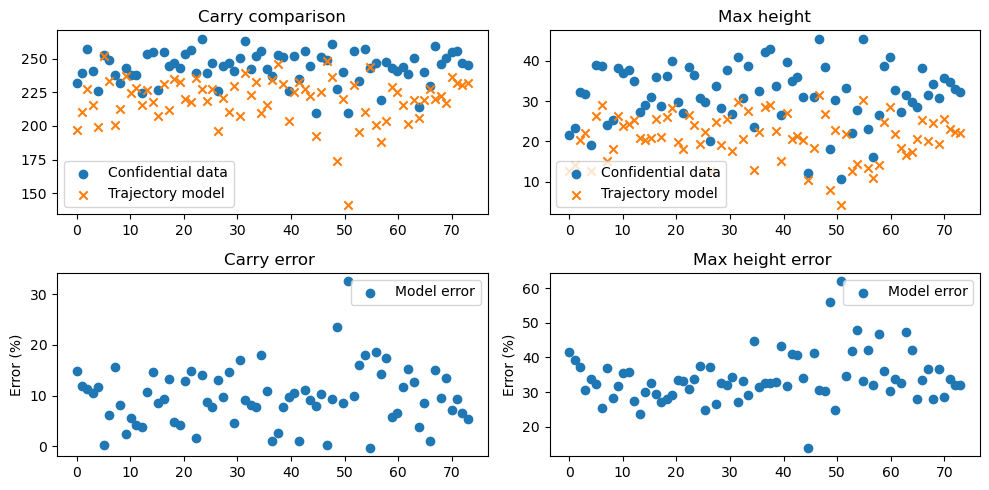

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(10, 5))

x = np.linspace(0,73,73)

# Calculate errors
pga_carry_error = ((df['Carry [m]'] - carry_pga) / df['Carry [m]']) * 100
pga_height_error = ((df['MaxHeight [m]'] - maxheight_pga) / df['MaxHeight [m]']) * 100


# Top-left
axes[0, 0].scatter(x,df['Carry [m]'], label='Confidential data')
axes[0, 0].scatter(x,carry_pga, marker='x', label='Trajectory model')
axes[0, 0].set_title("Carry comparison")
axes[0, 0].legend()

# Top-right
axes[0, 1].scatter(x,df['MaxHeight [m]'], label='Confidential data')
axes[0, 1].scatter(x,maxheight_pga, marker='x', label='Trajectory model')
axes[0, 1].set_title("Max height")
axes[0, 1].legend()

# Bottom-left
axes[1, 0].scatter(x,pga_carry_error, label='Model error')
axes[1, 0].set_title("Carry error ")
axes[1, 0].set_ylabel('Error (%)')
axes[1, 0].legend()

# Bottom-right
axes[1, 1].scatter(x,pga_height_error, label='Model error')
axes[1, 1].set_title("Max height error ")
axes[1, 1].set_ylabel('Error (%)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()
